Saved → stock_analysis.png

── Summary ──────────────────────────────────────────
Date Range  : 2016-04-01  →  2026-04-02
Total Days  : 2516
Price Range : $22.59  –  $286.19
Avg Daily Return    : 0.1053%
Std Daily Return    : 1.8227%
Max Daily Return    : 15.3288%
Min Daily Return    : -12.8647%
Avg Ann. Volatility : 28.63%
Max Ann. Volatility : 47.44%


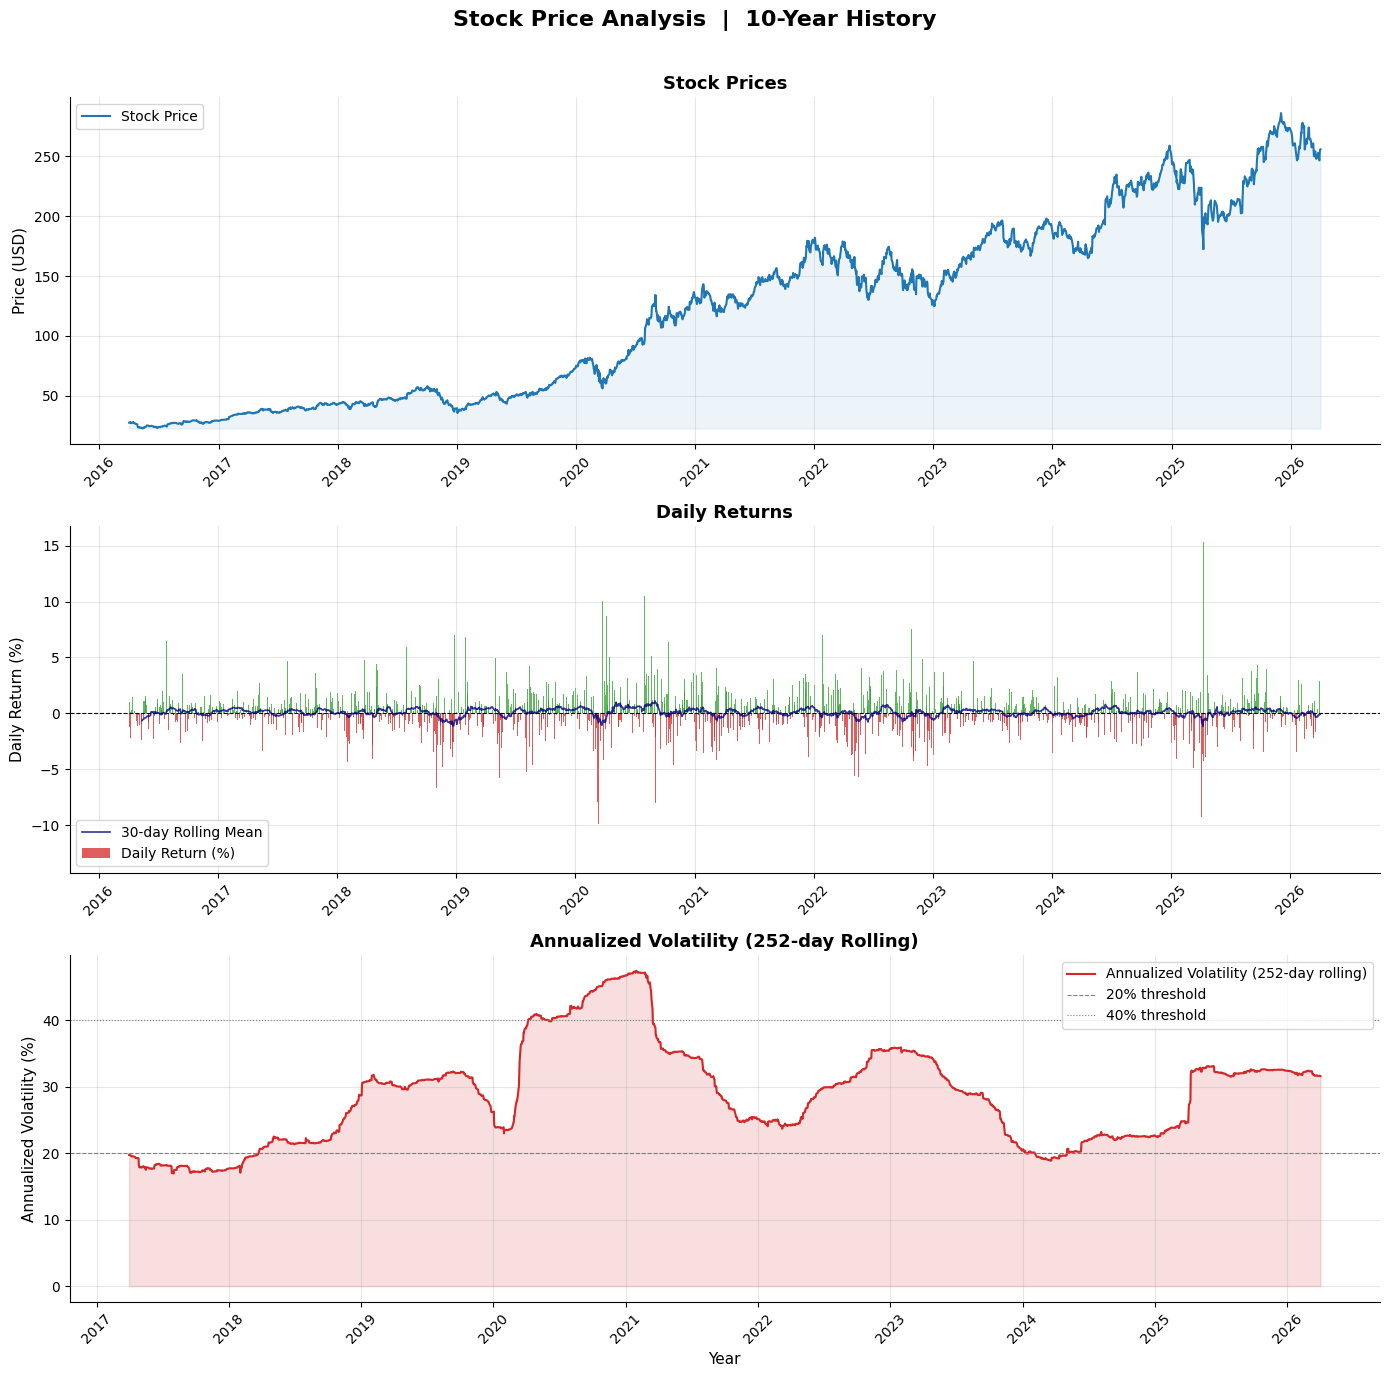

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Load Data ──────────────────────────────────────────────────────────────────
df = pd.read_excel('PriceHistory 10yrs.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ── Compute Daily Returns & Annualized Volatility ─────────────────────────────
# Use Price column to compute returns (matches professor's pct_change approach)
df['Daily Return'] = df['Price'].pct_change() * 100                   # in %
df['Annualized Volatility'] = (
    df['Daily Return'].rolling(window=252).std() * np.sqrt(252)       # in %
)

# ── Color palette ─────────────────────────────────────────────────────────────
C_PRICE  = '#1f77b4'   # blue
C_RET    = '#2ca02c'   # green
C_POS    = '#2ca02c'
C_NEG    = '#d62728'   # red
C_VOL    = '#d62728'
C_FILL   = '#d62728'

fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle('Stock Price Analysis  |  10-Year History', fontsize=16, fontweight='bold', y=0.98)

# ── Plot 1 · Stock Prices ─────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df['Date'], df['Price'], color=C_PRICE, linewidth=1.5, label='Stock Price')
ax1.fill_between(df['Date'], df['Price'].min(), df['Price'], alpha=0.08, color=C_PRICE)
ax1.set_title('Stock Prices', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())

# ── Plot 2 · Daily Returns ────────────────────────────────────────────────────
ax2 = axes[1]
returns = df['Daily Return'].dropna()
colors  = [C_POS if r >= 0 else C_NEG for r in df['Daily Return']]
ax2.bar(df['Date'], df['Daily Return'], color=colors, width=1.5, alpha=0.75, label='Daily Return (%)')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Rolling 30-day mean overlay
rolling_mean = df['Daily Return'].rolling(30).mean()
ax2.plot(df['Date'], rolling_mean, color='navy', linewidth=1.2,
         alpha=0.8, label='30-day Rolling Mean')

ax2.set_title('Daily Returns', fontsize=13, fontweight='bold')
ax2.set_ylabel('Daily Return (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())

# ── Plot 3 · Annualized Volatility ───────────────────────────────────────────
ax3 = axes[2]
ax3.plot(df['Date'], df['Annualized Volatility'], color=C_VOL, linewidth=1.5,
         label='Annualized Volatility (252-day rolling)')
ax3.fill_between(df['Date'], 0, df['Annualized Volatility'], alpha=0.15, color=C_FILL)

# Horizontal reference lines
for level, ls in [(20, '--'), (40, ':')]:
    ax3.axhline(level, color='grey', linewidth=0.8, linestyle=ls,
                label=f'{level}% threshold')

ax3.set_title('Annualized Volatility (252-day Rolling)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Annualized Volatility (%)', fontsize=11)
ax3.set_xlabel('Year', fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())

# ── Formatting ────────────────────────────────────────────────────────────────
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('stock_analysis.png', dpi=150, bbox_inches='tight')
print("Saved → stock_analysis.png")

# ── Summary Stats ─────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────────────")
print(f"Date Range  : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Total Days  : {len(df)}")
print(f"Price Range : ${df['Price'].min():.2f}  –  ${df['Price'].max():.2f}")
print(f"Avg Daily Return    : {df['Daily Return'].mean():.4f}%")
print(f"Std Daily Return    : {df['Daily Return'].std():.4f}%")
print(f"Max Daily Return    : {df['Daily Return'].max():.4f}%")
print(f"Min Daily Return    : {df['Daily Return'].min():.4f}%")
print(f"Avg Ann. Volatility : {df['Annualized Volatility'].mean():.2f}%")
print(f"Max Ann. Volatility : {df['Annualized Volatility'].max():.2f}%")